     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 40.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=199a9debd6c74cfe514dd8fc7aeae0074475f8dae0128ea74cbe1ddeeef53c1c
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib
モデルの精度 (RMSE): 0.070
決定係数 (R^2): 0.999

--- 各特徴量の影響度 ---
Oの電荷: 0.2866
O-H結合距離: -14.5439
計算値pKa: 0.9995
切片: 14.0482

--- 各物質の予測結果 ---


,物質名,Oの電荷,O-H結合距離,実験値pKa,計算値pKa,AI予測値,誤差
0,p-Cresol,-0.652435,0.96345,10.14,10.32,10.163665,0.023665
1,4-Methoxyphenol,-0.648434,0.96212,10.20,10.45,10.314090,0.114090
2,m-Cresol,-0.655323,0.96434,10.09,10.15,9.979979,-0.110021
3,4-Chlorophenol,-0.632476,0.96642,9.38,9.60,9.406553,0.026553
4,3-Chlorophenol,-0.625643,0.96798,9.02,9.12,8.906065,-0.113935
5,4-Hydroxybenzonitrile,-0.611903,0.96983,7.95,8.21,7.973556,0.023556
6,4-Nitrophenol,-0.594516,0.97221,7.15,7.43,7.164318,0.014318
7,3-Nitrophenol,-0.605342,0.97541,8.35,8.61,8.294079,-0.055921
8,"2,4-Dinitrophenol",-0.557489,0.97880,4.10,4.55,4.200539,0.100539
9,1-Naphthol,-0.649430,0.96516,9.34,9.55,9.370045,0.030045


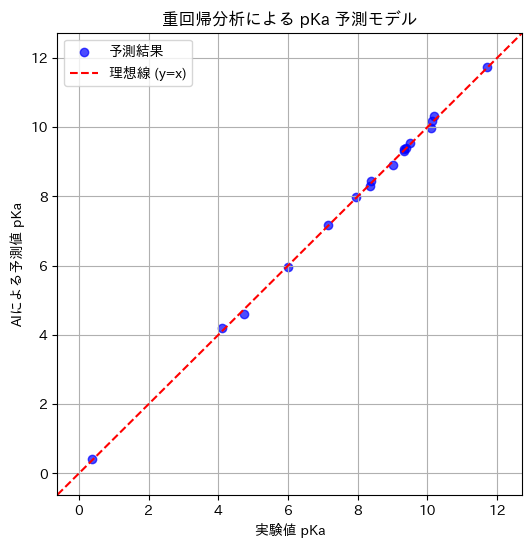

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

!pip install japanize-matplotlib
import japanize_matplotlib


df = pd.read_excel('/content/data1.xlsx')

X = df[['Oの電荷', 'O-H結合距離', '計算値pKa']]
y = df['実験値pKa']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"モデルの精度 (RMSE): {rmse:.3f}")
print(f"決定係数 (R^2): {r2:.3f}")

print("\n--- 各特徴量の影響度 ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"切片: {model.intercept_:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.7, label='予測結果')

print("\n--- 各物質の予測結果 ---")

df['AI予測値'] = y_pred
df['誤差'] = df['AI予測値'] - df['実験値pKa']


from IPython.display import display
display(df)

max_val = max(y.max(), y_pred.max()) + 1
min_val = min(y.min(), y_pred.min()) - 1
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='理想線 (y=x)')


plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('実験値 pKa')
plt.ylabel('AIによる予測値 pKa')
plt.title('重回帰分析による pKa 予測モデル')
plt.legend()
plt.grid(True)
plt.show()